# Factor Analysis

In [64]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

from   matplotlib import cm
import matplotlib.pyplot as plt

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")
prep_path = os.path.join(data_path, "PrepData")

In [3]:
path      = os.path.join(data_path, "FXTickerGuide.xlsx")
df_ticker = (pd
    .read_excel(io = path, sheet_name = "TickerGuide")
    .rename(columns = {
        "ticker"       : "fx_ticker",
        "etf_benchmark": "index_ticker"})
    .drop(columns = ["Active", "FACTOR_ACTIVE"])
    .assign(etf_ticker = lambda x: x.etf_ticker.str.split(" ").str[0])
    .assign(fx_name = lambda x: x.shorthand_name + " " + x.return_type.str.capitalize()))

In [4]:
FX_RENAMER = (df_ticker
    .set_index("fx_ticker")
    .fx_name
    .to_dict())

vol_renamer = {
    "lag_rtn" : "Lagged",
    "perf_rtn": "Perfect",
    "px_rtn"  : "None"}

param_renamer = {
    "param_val" : "Coef",
    "pvalue"    : r"$p$-value",
    "tvalue"    : r"$t$-value"}

RENAMER = {**FX_RENAMER, **vol_renamer, **param_renamer}

In [5]:
fx_country_mapper = (df_ticker[
    ["fx_ticker", "country"]]
    .set_index("fx_ticker")
    .country
    .to_dict())

FLOAT_FORMAT = lambda x: f"{x:.2f}"

# Analyzing Raw Equity Component of FX Returns

In [6]:
etf_path = os.path.join(prep_path, "ETFVolTargetedReturns.parquet")
df_etf   = (pd
    .read_parquet(path = etf_path, engine = "pyarrow")
    .drop(columns = ["PX_LAST", "vol"])
    .melt(id_vars = ["ticker", "date"], value_name = "etf_rtn")
    .dropna()
    .rename(columns = {"ticker": "etf_ticker"}))

In [7]:
fx_path = os.path.join(prep_path, "FXVolTargetedReturns.parquet")
df_fx   = (pd
    .read_parquet(path = fx_path, engine = "pyarrow")
    .loc[lambda x: x.variable.isin(["px_rtn", "perf_rtn", "lag_rtn"])]
    .rename(columns = {
        "value"   : "fx_rtn",
        "security": "fx_ticker"}))

In [8]:
df_combined = (df_fx
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    .merge(right = df_etf, how = "inner", on = ["etf_ticker", "variable", "date"]))

In [9]:
df_group = (df_combined
    .assign(group_var = lambda x: x.etf_ticker + "-" + x.fx_ticker + "-" + x.variable))

In [10]:
groups = df_group.group_var.drop_duplicates().sort_values().to_list()
models = {}

for group in groups: 

    df_tmp = (df_group
        .loc[lambda x: x.group_var == group]
        .set_index("date")
        .dropna())

    model = (sm
        .OLS(
            endog = df_tmp.fx_rtn,
            exog  = sm.add_constant(df_tmp.etf_rtn))
        .fit())

    models[group] = model

In [11]:
df_params_list = []
for key in models.keys():

    name               = key.split("-")[1]
    return_type_mapper = (df_ticker
        .set_index("fx_ticker")
        .return_type
        .to_dict())

    scaler_name = return_type_mapper[name]
    
    if scaler_name == "carry": scaler = -1
    else                     : scaler = 1

    tmp_model = models[key]
    df_param  = tmp_model.params.to_frame(name = "param_val").reset_index()
    df_pvalue = tmp_model.pvalues.to_frame(name = "pvalue").reset_index()
    df_tvalue = tmp_model.tvalues.to_frame(name = "tvalue").reset_index()

    df_add = (df_param
        .merge(right = df_pvalue, how = "inner", on = ["index"])
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .rename(columns = {"index": "param_name"})
        .assign(
            param_val = lambda x: scaler * x.param_val,
            group_var = key,
            tvalue    = lambda x: scaler * x.tvalue))

    df_params_list.append(df_add)

df_params = pd.concat(df_params_list)

In [12]:
df_param_prep = (df_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

df_beta = (df_param_prep
    .loc[lambda x: x.param_name == "etf_rtn"]
    .drop(columns = ["param_name"])
    .melt(id_vars = ["etf_ticker", "fx_ticker", "vol_target"]))

In [13]:
display(df_beta
    .assign(country = lambda x: x.fx_ticker.map(fx_country_mapper))
    .replace(RENAMER)
    .rename(columns = {
        "etf_ticker": "ETF",
        "fx_ticker" : "FX",
        "variable"  : "",
        "vol_target": "Vol. Target",
        "country"   : "Country"})
    .pivot(index = ["ETF", "Country", "FX"], columns = ["", "Vol. Target"], values = "value"))

Coef                          $p$-value  \
Vol. Target                     Lagged   Perfect      None         Lagged   
ETF  Country      FX                                                        
ARGT Argentina    ARS Carry   0.101849  0.105214  0.082595   7.548933e-11   
COLO Colombia     COP Carry   0.607601  0.612101  0.321565   0.000000e+00   
ECH  Chile        CLP Carry   0.611804  0.617712  0.269471   0.000000e+00   
EDEN Denmark      DKK Carry   0.341631  0.351876  0.145107   9.574851e-98   
EIDO Indonesia    IDR Carry   0.314555  0.318034  0.072750   5.437610e-88   
EIS  Israel       ISR Future  0.506367  0.513330  0.198298  6.232239e-288   
ENOR Norway       NOK Carry   0.675068  0.675460  0.335389   0.000000e+00   
                  NOK Future  0.660479  0.663634  0.326852   0.000000e+00   
ENZL New Zealand  NZD Carry   0.683346  0.689257  0.361125   0.000000e+00   
                  NZD Future  0.659743  0.668783  0.354008   0.000000e+00   
EPHE Philippines  PHP Carry   0.247601  0.250208  0.051285   7.695537e-56   
EPOL Poland       PLN Carry   0.655118  0.660935  0.291538   0.000000e+00   
                  PLN Future  0.638348  0.645011  0.286513   0.000000e+00   
EPU  Peru         PEN Carry   0.408195  0.397504  0.094871  1.986273e-163   
EWA  Australia    AUD Carry   0.626709  0.631803  0.303772   0.000000e+00   
                  AUD Future  0.588333  0.595381  0.277878   0.000000e+00   
EWC  Canada       CAD Carry   0.579834  0.589358  0.225581   0.000000e+00   
                  CAD Future  0.539584  0.551124  0.205662   0.000000e+00   
EWD  Sweden       SEK Carry   0.470199  0.478611  0.198889   0.000000e+00   
                  SEK Future  0.507304  0.512513  0.210591   0.000000e+00   
EWH  Hong Kong    HKD Carry   0.101528  0.098934  0.001376   9.745203e-18   
EWJ  Japan        JPY Carry   0.022288  0.028840  0.027247   5.430419e-02   
                  JPY Future  0.034192  0.038730  0.040858   3.118741e-03   
EWL  Switzerland  CHF Carry   0.272428  0.284813  0.126456  4.351381e-129   
                  CHF Future  0.270471  0.281075  0.128382  3.890286e-128   
EWM  Malaysia     MYR Carry   0.278854  0.282544  0.055701   4.053017e-44   
EWS  Singapore    SGD Carry   0.454728  0.459867  0.086144   0.000000e+00   
EWT  Taiwan       TWD Carry   0.279014  0.275284  0.034209  1.090218e-107   
EWU  UK           GBP Carry   0.397074  0.398586  0.163831  8.514094e-280   
                  GBP Future  0.380652  0.383962  0.155778  1.118275e-258   
EWW  Mexico       MXN Carry   0.680267  0.678136  0.272863   0.000000e+00   
                  MXN Future  0.637485  0.636404  0.243375   0.000000e+00   
EWY  Korea        KRW Carry   0.374342  0.372826  0.112106  2.022629e-208   
                  KRW Future  0.587632  0.588867  0.191638   0.000000e+00   
EWZ  Brazil       BRL Carry   0.726161  0.724754  0.309207   0.000000e+00   
                  BRL Future  0.681382  0.682795  0.284512   0.000000e+00   
EZA  South Africa ZAR Carry   0.729761  0.742539  0.370722   0.000000e+00   
EZU  Euro         EUR Carry   0.376515  0.392741  0.151981  4.499313e-219   
                  EUR Future  0.364563  0.380631  0.144419  7.456938e-207   
GLCR Iceland      ISK Carry   0.411375  0.434747  0.155909   1.304232e-10   
INDA India        INR Carry   0.382869  0.385360  0.109518  5.649249e-127   
                  INR Future  0.569045  0.574812  0.165117  6.010177e-280   
MCHI China        CNY Carry   0.224493  0.223868  0.034573   4.017831e-44   
                  CNY Future -0.214985 -0.212738 -0.036809   1.389648e-34   
THD  Thailand     THB Carry   0.345423  0.352643  0.063793  2.192767e-126   
TUR  Turkey       TRY Carry   0.650008  0.640831  0.278913   0.000000e+00   

                                                            $t$-value  \
Vol. Target                         Perfect           None     Lagged   
ETF  Country      FX                                                    
ARGT Argentina    ARS Carry    5.250546e-

In [14]:
df_spread = (pd
    .read_parquet(path = etf_path, engine = "pyarrow")
    .drop(columns = ["PX_LAST", "vol"])
    .melt(id_vars = ["date", "ticker"])
    .dropna()
    .pivot(index = ["date", "variable"], columns = "ticker", values = "value")
    .reset_index()
    .melt(id_vars = ["date", "variable", "SPY"])
    .dropna()
    .assign(spread = lambda x: x.value - x.SPY)
    [["date", "variable", "ticker", "spread"]]
    .rename(columns = {"ticker": "etf_ticker"}))

In [15]:
df_combined = (df_fx
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    .merge(right = df_spread, how = "inner", on = ["date", "etf_ticker", "variable"])
    .assign(group_var = lambda x: x.etf_ticker + "-" + x.fx_ticker + "-" + x.variable))

In [16]:
groups = df_combined.group_var.drop_duplicates().sort_values().to_list()
models = {}

for group in groups: 

    df_tmp = (df_combined
        .loc[lambda x: x.group_var == group]
        .set_index("date")
        .dropna())
    
    model = (sm
        .OLS(
            endog = df_tmp.fx_rtn,
            exog  = sm.add_constant(df_tmp.spread))
        .fit())

    models[group] = model

In [17]:
df_params_list = []
for key in models.keys():

    name               = key.split("-")[1]
    return_type_mapper = (df_ticker
        .set_index("fx_ticker")
        .return_type
        .to_dict())

    scaler_name = return_type_mapper[name]
    
    if scaler_name == "carry": scaler = -1
    else                     : scaler = 1

    tmp_model = models[key]
    df_param  = tmp_model.params.to_frame(name = "param_val").reset_index()
    df_pvalue = tmp_model.pvalues.to_frame(name = "pvalue").reset_index()
    df_tvalue = tmp_model.tvalues.to_frame(name = "tvalue").reset_index()

    df_add = (df_param
        .merge(right = df_pvalue, how = "inner", on = ["index"])
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .rename(columns = {"index": "param_name"})
        .assign(
            param_val = lambda x: scaler * x.param_val,
            group_var = key,
            tvalue    = lambda x: scaler * x.tvalue))

    df_params_list.append(df_add)

df_params = pd.concat(df_params_list)

In [18]:
df_param_prep = (df_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

display(df_param_prep
    .loc[lambda x: x.param_name == "spread"]
    .drop(columns = ["param_name"])
    .melt(id_vars = ["etf_ticker", "fx_ticker", "vol_target"])
    .pivot(index = ["etf_ticker", "fx_ticker"], columns = ["variable", "vol_target"], values = "value"))

variable                   param_val                             pvalue  \
vol_target                   lag_rtn  perf_rtn    px_rtn        lag_rtn   
etf_ticker fx_ticker                                                      
ARGT       USDARSCR Curncy  0.080743  0.083306  0.125669   2.649483e-06   
COLO       USDCOPCR Curncy  0.321077  0.321118  0.272432  6.565494e-100   
ECH        USDCLPCR Curncy  0.364574  0.366696  0.257177  1.287486e-126   
EDEN       USDDKKCR Curncy  0.326825  0.331011  0.169822   7.054077e-70   
EIDO       USDIDRCR Curncy  0.203905  0.206571  0.085922   4.402108e-34   
EIS        IS1 Curncy       0.371592  0.372360  0.227051   7.651987e-83   
ENOR       NO1 Curncy       0.485049  0.484924  0.381957  5.501835e-152   
           USDNOKCR Curncy  0.469580  0.468869  0.372797  4.618324e-141   
ENZL       NV1 Curncy       0.395259  0.401801  0.297142  8.885259e-135   
           USDNZDCR Curncy  0.368666  0.375285  0.279014  1.646628e-115   
EPHE       USDPHPCR Curncy  0.177013  0.176129  0.054049   9.045571e-28   
EPOL       PP1 Curncy       0.470905  0.475939  0.358882  8.916526e-175   
           USDPLNCR Curncy  0.471540  0.476240  0.358221  6.026790e-171   
EPU        USDPENCR Curncy  0.165405  0.155399  0.072596   1.764648e-25   
EWA        AD1 Curncy       0.417389  0.418436  0.303622  5.506011e-236   
           USDAUDCR Curncy  0.401071  0.403268  0.306839  2.235509e-214   
EWC        CD1 Curncy       0.383922  0.393078  0.191609  4.045114e-180   
           USDCADCR Curncy  0.331330  0.338118  0.169995  1.202645e-131   
EWD        SE1 Curncy       0.575390  0.579671  0.348897  1.338567e-264   
           USDSEKCR Curncy  0.445865  0.454682  0.266320  8.396547e-250   
EWH        USDHKDCR Curncy  0.050090  0.045946  0.000898   1.556709e-04   
EWJ        JY1 Curncy       0.304095  0.308328  0.182457  2.300104e-117   
           USDJPYCR Curncy  0.313510  0.318604  0.177708  1.511005e-124   
EWL        SF1 Curncy       0.471828  0.475004  0.250482   0.000000e+00   
           USDCHFCR Curncy  0.489434  0.491429  0.256827   0.000000e+00   
EWM        USDMYRCR Curncy  0.196339  0.194019  0.041133   2.697244e-21   
EWS        USDSGDCR Curncy  0.297749  0.296174  0.072930   6.472307e-96   
EWT        USDTWDCR Curncy  0.287855  0.281734  0.045385   5.254807e-79   
EWU        BP1 Curncy       0.446158  0.446509  0.232764  6.204642e-221   
           USDGBPCR Curncy  0.449646  0.448543  0.236468  2.889150e-221   
EWW        PE1 Curncy       0.313190  0.307656  0.246884  1.509161e-130   
           USDMXNCR Curncy  0.308616  0.305571  0.261883  2.442909e-105   
EWY        KO1 Curncy       0.488147  0.500508  0.282880  2.796519e-168   
           USDKRWCR Curncy  0.391747  0.393966  0.166704  2.435653e-156   
EWZ        BR1 Curncy       0.424006  0.427682  0.343103  1.053469e-232   
           USDBRLCR Curncy  0.424700  0.427124  0.365392  5.533413e-231   
EZA        USDZARCR Curncy  0.450221  0.469091  0.464624  3.171222e-214   
EZU        EC1 Curncy       0.653522  0.679467  0.339314  1.863184e-309   
           USDEURCR Curncy  0.656843  0.680982  0.346810  4.951116e-308   
GLCR       USDISKCR Curncy  0.326999  0.335530  0.155230   5.925950e-07   
INDA       SIR1 Curncy      0.330009  0.338157  0.163848   2.940524e-72   
           USDINRCR Curncy  0.312841  0.317214  0.132569   4.943222e-72   
MCHI       UCA1 Curncy     -0.173719 -0.170181 -0.039826   8.723511e-21   
           USDCNYCR Curncy  0.174651  0.173607  0.035008   1.310997e-23   
THD        USDTHBCR Curncy  0.275744  0.279027  0.083792   2.311601e-67   
TUR        USDTRYCR Curncy  0.330443  0.322760  0.299905  2.557139e-126   

variable                                                     tvalue  \
vol_target                       perf_rtn         px_rtn    lag_rtn   
etf_ticker fx_ticker                                                  
ARGT       USDARSCR Curncy   2.443279e-06   1.122526e-07   4.703444   
COLO       USDCOPCR Curncy  1.779275e-10

In [103]:
(df_spread
    .merge(right = df_etf, how = "inner", on = ["date", "variable", "etf_ticker"])
    .drop(columns = ["date"])
    .groupby(["variable", "etf_ticker"])
    .agg("corr")
    .reset_index()
    .drop(columns = ["level_2", "spread"])
    .loc[lambda x: x.etf_rtn != 1]
    .pivot(index = "etf_ticker", columns = "variable", values = "etf_rtn"))

variable,lag_rtn,perf_rtn,px_rtn
etf_ticker,,,
ARGT,0.480494,0.457999,0.820209
COLO,0.518322,0.520197,0.717540
ECH,0.481106,0.478643,0.690901
EDEN,0.447823,0.454781,0.539921
EIDO,0.485130,0.483083,0.772225
EIS,0.395727,0.392639,0.517196
ENOR,0.446615,0.451110,0.714005
ENZL,0.480337,0.493574,0.566463
EPHE,0.497145,0.501762,0.670980


In [26]:
df_combined = (df_fx
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    .merge(right = df_spread, how = "inner", on = ["date", "etf_ticker", "variable"])
    .merge(right = df_etf, how = "inner", on = ["date", "etf_ticker", "variable"])
    .assign(group_var = lambda x: x.etf_ticker + "-" + x.fx_ticker + "-" + x.variable))

In [43]:
group_vars = df_combined.group_var.drop_duplicates().sort_values().to_list()
models = {}

for group_var in group_vars: 

    df_tmp = (df_combined
        .loc[lambda x: x.group_var == group_var]
        .set_index("date")
        [["fx_rtn", "spread", "etf_rtn"]]
        .dropna())

    model = (sm
        .OLS(
            endog = df_tmp.fx_rtn,
            exog  = sm.add_constant(df_tmp[["spread", "etf_rtn"]]))
        .fit())
    
    models[group_var] = model

In [46]:
df_params_list = []
for key in models.keys():

    name               = key.split("-")[1]
    return_type_mapper = (df_ticker
        .set_index("fx_ticker")
        .return_type
        .to_dict())

    scaler_name = return_type_mapper[name]
    
    if scaler_name == "carry": scaler = -1
    else                     : scaler = 1

    tmp_model = models[key]
    df_param  = tmp_model.params.to_frame(name = "param_val").reset_index()
    df_pvalue = tmp_model.pvalues.to_frame(name = "pvalue").reset_index()
    df_tvalue = tmp_model.tvalues.to_frame(name = "tvalue").reset_index()

    df_add = (df_param
        .merge(right = df_pvalue, how = "inner", on = ["index"])
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .rename(columns = {"index": "param_name"})
        .assign(
            param_val = lambda x: scaler * x.param_val,
            group_var = key,
            tvalue    = lambda x: scaler * x.tvalue))

    df_params_list.append(df_add)

df_params = pd.concat(df_params_list)

In [48]:
df_param_prep = (df_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

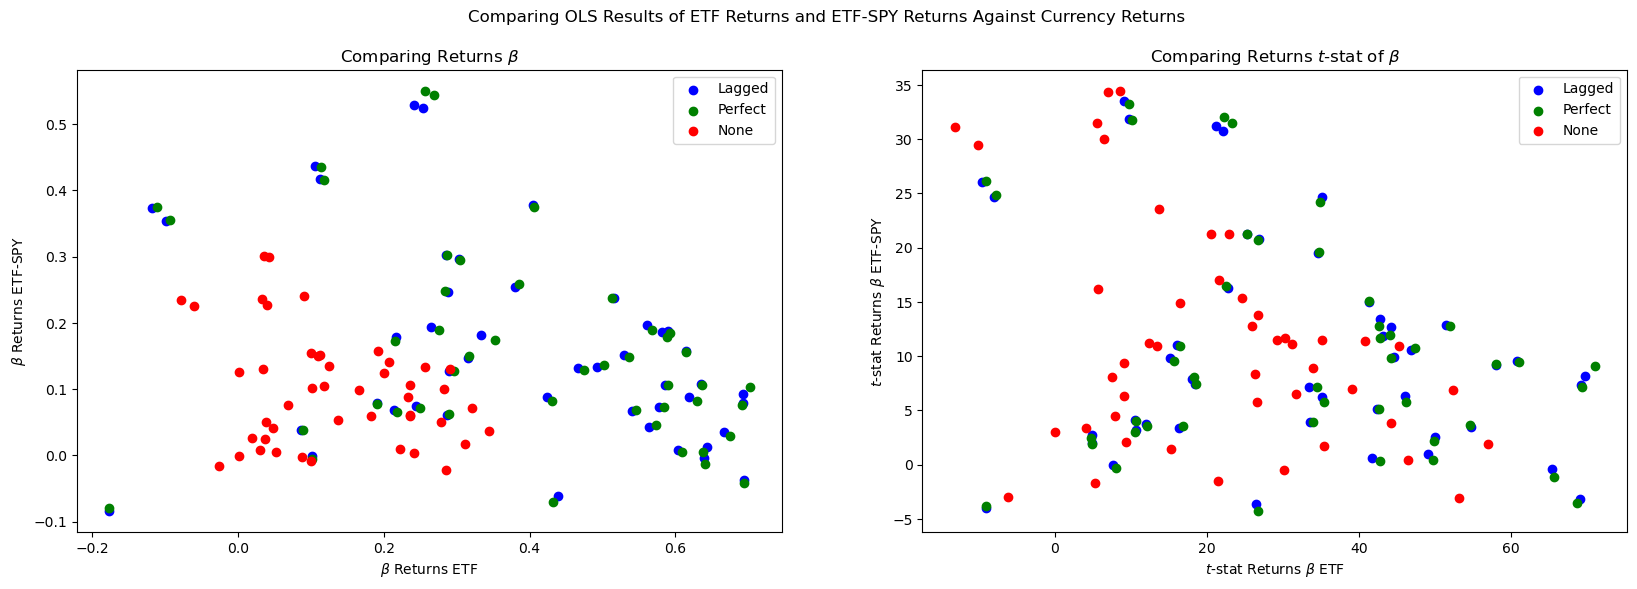

In [101]:
fig, axes   = plt.subplots(ncols = 2, figsize = (20,6))
vol_targets = df_param_prep.vol_target.drop_duplicates().sort_values().to_list()
colors      = ["blue", "green", "red"]

for vol_target, color in zip(vol_targets, colors): 
    
    df_plot_tmp = (df_param_prep
        .loc[lambda x: (x.vol_target == vol_target) & (x.param_name != "const")])

    df_plot1 = (df_plot_tmp
        .drop(columns = ["pvalue", "tvalue", "vol_target"])
        .pivot(index = ["etf_ticker", "fx_ticker"], columns = "param_name", values = "param_val"))

    df_plot2 = (df_plot_tmp
        .drop(columns = ["pvalue", "param_val", "vol_target"])
        .pivot(index = ["etf_ticker", "fx_ticker"], columns = "param_name", values = "tvalue"))

    axes[0].scatter(
        x     = df_plot1["etf_rtn"],
        y     = df_plot1["spread"],
        color = color,
        label = RENAMER[vol_target])

    axes[1].scatter(
        x     = df_plot2["etf_rtn"],
        y     = df_plot2["spread"],
        color = color,
        label = RENAMER[vol_target])

    axes[0].legend()
    axes[1].legend()


axes[0].set_xlabel(r"$\beta$ Returns ETF")
axes[0].set_ylabel(r"$\beta$ Returns ETF-SPY")
axes[0].set_title(r"Comparing Returns $\beta$")

axes[1].set_xlabel(r"$t$-stat Returns $\beta$ ETF")
axes[1].set_ylabel(r"$t$-stat Returns $\beta$ ETF-SPY")
axes[1].set_title(r"Comparing Returns $t$-stat of $\beta$")

fig.suptitle("Comparing OLS Results of ETF Returns and ETF-SPY Returns Against Currency Returns")
plt.show()